# MOOGP Orthogonality and Trend Recovery

This notebook checks the manuscript orthogonality condition at the kernel level and then shows, on the Forrester example, that the orthogonal MOOGP separates the linear trend more cleanly than the non-orthogonal model.

To isolate the `orthogonal` flag itself, all model fits below use the slow dense path with a fixed `Psi = I`.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

sys.path.append(os.path.abspath(".."))

In [2]:
import matplotlib.pyplot as plt
import numpy as np

try:
    import pandas as pd
except ImportError:
    pd = None

from moogp.datasets import generate_forrester_data, log_lhs_1d_rescaled
from moogp.forrester_illustration import fit_moogp_forrester, get_model_trend_betas_raw
from moogp.kernels import make_c_star_matrix


In [3]:
TRUE_TREND_BETAS_RAW = np.array([
    [0.0, 2.5, -1.5],
    [0.0, 5.0, -5.0],
])


def forrester_true_trend(X_raw):
    x = np.asarray(X_raw).reshape(-1, 1)
    zero = np.zeros_like(x)
    trend2 = 5.0 * (x - 0.5) + 5.0
    trend3 = -5.0 * (x - 0.5) - 4.0
    return np.concatenate([zero, trend2, trend3], axis=1)


def show_rows(rows):
    if pd is not None:
        return pd.DataFrame(rows)
    return rows


def fit_pair(data, seed, maxiter=300):
    common = dict(
        n_train=data["X"].shape[0],
        seed=seed,
        Psi=np.eye(3),
        use_fast=False,
        data=data,
        maxiter=maxiter,
    )
    moogp, _, _, _ = fit_moogp_forrester(orthogonal=True, **common)
    mogp, _, _, _ = fit_moogp_forrester(orthogonal=False, **common)
    return moogp, mogp


## 1. Kernel-Level Orthogonality Check

The manuscript condition is that the orthogonalized kernel `c*` should be orthogonal to the regression space. For `g(x) = (1, x)` on `[-1, 1]`, both moments below should be near zero when `orthogonal=True`, and clearly non-zero when `orthogonal=False`.

max |∫ c*(x, x') dx|: 7.214272734174074e-08
max |∫ x c*(x, x') dx|: 1.1937636386675186e-07


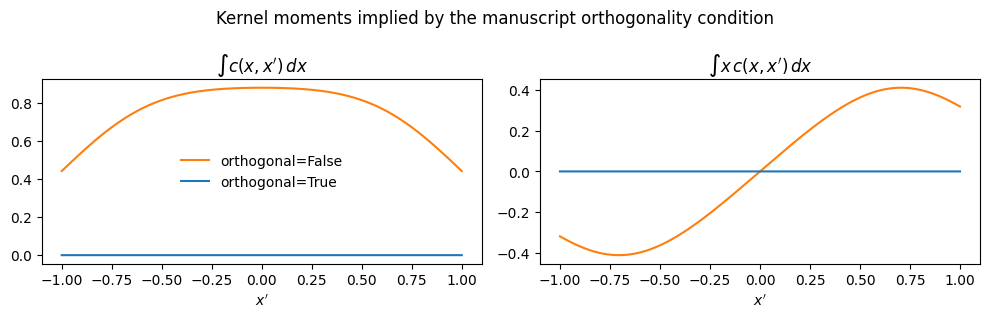

In [4]:
xs = np.linspace(-1.0, 1.0, 2001).reshape(-1, 1)
terms = [None, 1]
ell = np.array([0.5])
sigma2 = 1.0

C_orth = make_c_star_matrix(xs, xs, ell=ell, sigma2=sigma2, terms=terms, orthogonal=True)
C_plain = make_c_star_matrix(xs, xs, ell=ell, sigma2=sigma2, terms=terms, orthogonal=False)

I0_orth = np.trapz(C_orth, x=xs[:, 0], axis=0)
I1_orth = np.trapz(C_orth * xs[:, 0][:, None], x=xs[:, 0], axis=0)

I0_plain = np.trapz(C_plain, x=xs[:, 0], axis=0)
I1_plain = np.trapz(C_plain * xs[:, 0][:, None], x=xs[:, 0], axis=0)

assert np.max(np.abs(I0_orth)) < 1e-3
assert np.max(np.abs(I1_orth)) < 1e-3
assert np.max(np.abs(I0_plain)) > 1e-1
assert np.max(np.abs(I1_plain)) > 1e-1

print("max |∫ c*(x, x') dx|:", float(np.max(np.abs(I0_orth))))
print("max |∫ x c*(x, x') dx|:", float(np.max(np.abs(I1_orth))))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharex=True)
axes[0].plot(xs[:, 0], I0_plain, label="orthogonal=False", color="tab:orange")
axes[0].plot(xs[:, 0], I0_orth, label="orthogonal=True", color="tab:blue")
axes[0].set_title(r"$\int c(x, x')\,dx$")
axes[0].set_xlabel(r"$x'$")
axes[0].legend(frameon=False)

axes[1].plot(xs[:, 0], I1_plain, label="orthogonal=False", color="tab:orange")
axes[1].plot(xs[:, 0], I1_orth, label="orthogonal=True", color="tab:blue")
axes[1].set_title(r"$\int x\,c(x, x')\,dx$")
axes[1].set_xlabel(r"$x'$")

fig.suptitle("Kernel moments implied by the manuscript orthogonality condition")
fig.tight_layout()


## 2. Single Log-LHS Forrester Fit

This is the hard design from the manuscript: data cluster near `x = 1`, which makes trend/GP confounding more severe. We compare the fitted linear trend for output 3 against the known true linear component.

In [5]:
seed = 0
n_train = 25

X_log = log_lhs_1d_rescaled(
    n_train,
    seed=seed,
    xmin=1e-3,
    cluster="right",
    include_x0=False,
    shuffle=False,
)
data_log = generate_forrester_data(
    n=n_train,
    seed=seed,
    with_error=True,
    error_per_output=[10.0, 1.0, 0.05],
    X_override=X_log,
)

moogp, mogp = fit_pair(data_log, seed=seed)

assert moogp.cache["used_fast"] is False
assert mogp.cache["used_fast"] is False

beta_moogp = get_model_trend_betas_raw(moogp)
beta_mogp = get_model_trend_betas_raw(mogp)

rows = [
    {
        "model": "MOOGP orthogonal=True",
        "output3_beta0": beta_moogp[0, 2],
        "output3_beta1": beta_moogp[1, 2],
        "output3_beta_error_norm": np.linalg.norm(beta_moogp[:, 2] - TRUE_TREND_BETAS_RAW[:, 2]),
    },
    {
        "model": "MOGP orthogonal=False",
        "output3_beta0": beta_mogp[0, 2],
        "output3_beta1": beta_mogp[1, 2],
        "output3_beta_error_norm": np.linalg.norm(beta_mogp[:, 2] - TRUE_TREND_BETAS_RAW[:, 2]),
    },
    {
        "model": "True trend",
        "output3_beta0": TRUE_TREND_BETAS_RAW[0, 2],
        "output3_beta1": TRUE_TREND_BETAS_RAW[1, 2],
        "output3_beta_error_norm": 0.0,
    },
]
show_rows(rows)


,model,output3_beta0,output3_beta1,output3_beta_error_norm
0,MOOGP orthogonal=True,-0.269519,-8.069324,3.306786
1,MOGP orthogonal=False,0.321612,-10.744082,6.026006
2,True trend,-1.500000,-5.000000,0.000000


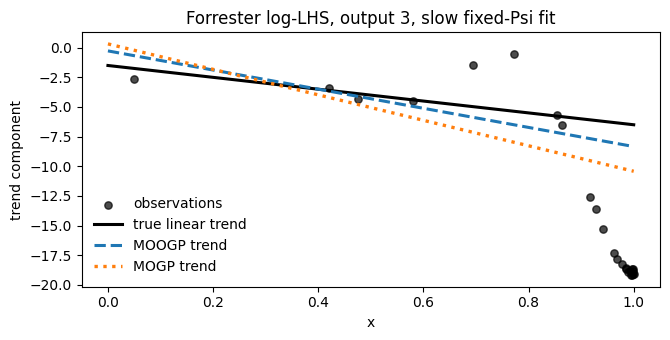

In [6]:
X_plot = np.linspace(0.0, 1.0, 400).reshape(-1, 1)
true_trend = forrester_true_trend(X_plot)[:, 2]
moogp_trend = beta_moogp[0, 2] + beta_moogp[1, 2] * X_plot[:, 0]
mogp_trend = beta_mogp[0, 2] + beta_mogp[1, 2] * X_plot[:, 0]

fig, ax = plt.subplots(figsize=(6.8, 3.5))
ax.scatter(data_log["X"][:, 0], data_log["y"][:, 2], color="black", s=28, alpha=0.7, label="observations")
ax.plot(X_plot[:, 0], true_trend, color="black", linewidth=2.2, label="true linear trend")
ax.plot(X_plot[:, 0], moogp_trend, color="tab:blue", linestyle="--", linewidth=2.2, label="MOOGP trend")
ax.plot(X_plot[:, 0], mogp_trend, color="tab:orange", linestyle=":", linewidth=2.4, label="MOGP trend")
ax.set_title("Forrester log-LHS, output 3, slow fixed-Psi fit")
ax.set_xlabel("x")
ax.set_ylabel("trend component")
ax.legend(frameon=False)
fig.tight_layout()


## 3. Multi-Seed Trend-Recovery Study

The next cell repeats the hard log-LHS design across 10 seeds. We measure the Euclidean error in the recovered raw-basis trend coefficients for outputs 2 and 3.

If the orthogonality constraint is doing what the manuscript intends, the orthogonal model should consistently have smaller trend-coefficient error.

In [7]:
study_rows = []
for seed in range(10):
    X_log = log_lhs_1d_rescaled(
        25,
        seed=seed,
        xmin=1e-3,
        cluster="right",
        include_x0=False,
        shuffle=False,
    )
    data_log = generate_forrester_data(
        n=25,
        seed=seed,
        with_error=True,
        error_per_output=[10.0, 1.0, 0.05],
        X_override=X_log,
    )
    moogp, mogp = fit_pair(data_log, seed=seed)
    beta_moogp = get_model_trend_betas_raw(moogp)
    beta_mogp = get_model_trend_betas_raw(mogp)

    for output_idx in (1, 2):
        study_rows.append(
            {
                "seed": seed,
                "output": output_idx + 1,
                "orthogonal_beta_error": np.linalg.norm(beta_moogp[:, output_idx] - TRUE_TREND_BETAS_RAW[:, output_idx]),
                "nonorthogonal_beta_error": np.linalg.norm(beta_mogp[:, output_idx] - TRUE_TREND_BETAS_RAW[:, output_idx]),
            }
        )

study = pd.DataFrame(study_rows) if pd is not None else study_rows
study


,seed,output,orthogonal_beta_error,nonorthogonal_beta_error
0,0,2,4.876944,7.757580
1,0,3,3.306786,6.026006
2,1,2,3.272699,7.981511
3,1,3,5.039356,9.084894
4,2,2,0.597512,5.578025
5,2,3,3.983890,8.932469
6,3,2,3.772816,6.013413
7,3,3,3.731565,7.406723
8,4,2,2.447694,5.796538
9,4,3,4.042135,8.832803


,output,orthogonal_beta_error,nonorthogonal_beta_error
0,2,3.391922,7.136957
1,3,4.089409,8.362824


/var/folders/9y/nhtlk1191r78kf_7vfn0gm880000gn/T/ipykernel_17579/2113559790.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/9y/nhtlk1191r78kf_7vfn0gm880000gn/T/ipykernel_17579/2113559790.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


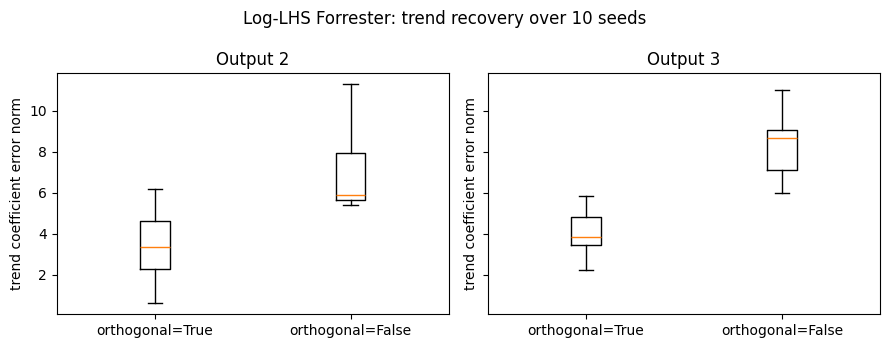

In [8]:
if pd is not None:
    summary = (
        study.groupby("output")[["orthogonal_beta_error", "nonorthogonal_beta_error"]]
        .mean()
        .reset_index()
    )
    display(summary)
    assert np.all(summary["orthogonal_beta_error"] < summary["nonorthogonal_beta_error"])
    assert np.all(
        study["orthogonal_beta_error"].to_numpy() < study["nonorthogonal_beta_error"].to_numpy()
    )

    fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.5), sharey=True)
    for ax, output_idx in zip(axes, [2, 3]):
        sub = study[study["output"] == output_idx]
        ax.boxplot(
            [sub["orthogonal_beta_error"], sub["nonorthogonal_beta_error"]],
            labels=["orthogonal=True", "orthogonal=False"],
        )
        ax.set_title(f"Output {output_idx}")
        ax.set_ylabel("trend coefficient error norm")
    fig.suptitle("Log-LHS Forrester: trend recovery over 10 seeds")
    fig.tight_layout()
else:
    print(study)


Interpretation:

- The kernel-level moment check shows that `orthogonal=True` is enforcing the manuscript condition `\int g(x) c^*(x, x') dx = 0` for the regression basis.
- In the hard log-LHS Forrester setting, the orthogonal MOOGP consistently recovers the output-2/output-3 linear trend coefficients more accurately than the non-orthogonal model when the rest of the setup is held fixed.